# Red or Blue Who Wins?

**Name(s)**: Shriya Pattapu, Milo Palmquist

**Website Link**: https://spattapu1.github.io/LoL-Statistical-Analysis/

In [15]:
import pandas as pd
import numpy as np
from pathlib import Path
import sklearn as sk
from scipy import stats

import plotly.express as px
pd.options.plotting.backend = 'plotly'

from dsc80_utils import * # Feel free to uncomment and use this.
pio.renderers.default = 'notebook_connected'


In professional play does the side of the map you are on affect your win rate? -> Sample from data this diff in wins from blue and red in samples (perm tes) -> (two tail)
classify a team or blue side based on other features.

## Step 1: Introduction

League of Lengends is a multiplayer online battle arena game in which two teams of five play against each other with the objective of destroying the other team's base. The game has an extremely large player base, and there are many competitve leagues for professional teams. The dataset we are working with contains information from individual pro-play games that show both the performance overall and throughout the game for both the players and teams as well as the result of each game. 

For this project, we would like to answer the following question: "Are you more likely perform better if you are on the blue side?" In League of Legends, the map is square-shaped, and players play in three lanes. The top lane is along the left and top edges, the bottom lane is along the right and bottom edges, and the mid lane is along the diagonal from the bottom left corner to the top right one. Each side's base is situated at one of these two corners with blue side at the bottom and red side at the top, and which side a team is on is determined randomly at the start of the game. In the League of Legends community, many players think that there is an advantage to being on the blue side. This may be attributed to the way the in-game display is set up, as there are generally more features at the bottom of a player's screen, and this may hinder players on the red side's ability to smoothly interact with the part of the screen where their enemies will show up a majority of the game. Using this dataset, we can see if even the best of the best are safe from the alleged effect this coin flip. Assuming the skills of each team is similar, then the proportion of wins on one side should not be significantly different from the other.

## Step 2: Data Cleaning and Exploratory Data Analysis

In [2]:
df = pd.read_csv("main.csv")

/var/folders/ct/mkdcx0p53gqgmfvf541_sql40000gn/T/ipykernel_3287/3455604807.py:1: DtypeWarning:

Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.



In [3]:
complete = df[df['datacompleteness'] == 'complete']
complete['gamelength'] = np.round(complete['gamelength'] / 60, 2)

In [4]:
teams = complete[complete['position'] == 'team'][['gameid','league','side','teamname', 'gamelength', 'result', 'teamkills', 'earnedgold', 'damagetochampions', 'xpat25', 'csat25', 'dragons', 'barons']]

In [5]:
teams.head()

,gameid,league,side,teamname,...,xpat25,csat25,dragons,barons
10,ESPORTSTMNT01_2690210,LCKC,Blue,BRION Challengers,...,45960.0,767.0,1.0,0.0
11,ESPORTSTMNT01_2690210,LCKC,Red,Nongshim Esports Academy,...,49931.0,864.0,3.0,0.0
22,ESPORTSTMNT01_2690219,LCKC,Blue,T1 Esports Academy,...,49409.0,895.0,1.0,0.0
23,ESPORTSTMNT01_2690219,LCKC,Red,Liiv SANDBOX Youth,...,57155.0,928.0,4.0,2.0
46,ESPORTSTMNT01_2690227,LCKC,Blue,KT Rolster Challengers,...,52441.0,912.0,4.0,1.0


In [6]:
win_rates_per_side = (teams[teams['result'] == 1].groupby('side').size() / teams.groupby('side').size()).to_frame().reset_index()

fig = px.bar(win_rates_per_side, x = 'side', y = 0, color='side', title = 'Win Rate Per Side', 
             color_discrete_map={'Blue': 'blue', 'Red': 'red'},)
fig.update_layout(yaxis_title="Win Rate")
fig

In [7]:
fig = go.Figure()
fig.add_trace(go.Histogram(x=teams[teams['side'] == 'Red']['teamkills'], name='Red',marker_color='red'))
fig.add_trace(go.Histogram(x=teams[teams['side'] == 'Blue']['teamkills'], name='Blue',marker_color='blue'))
fig.update_layout(barmode='overlay')
fig.update_traces(opacity=0.55)
fig.update_layout(yaxis_title="count")
fig.update_layout(xaxis_title="total kills")
fig.update_layout(title="Total Kills by Side")
fig

In [8]:
fig = go.Figure()
fig.add_trace(go.Histogram(x=teams[teams['side'] == 'Red']['earnedgold'], name='Red',marker_color='red'))
fig.add_trace(go.Histogram(x=teams[teams['side'] == 'Blue']['earnedgold'], name='Blue',marker_color='blue'))
fig.update_layout(barmode='overlay')
fig.update_traces(opacity=0.75)
fig.update_layout(yaxis_title="count")
fig.update_layout(xaxis_title="total earned gold")
fig.update_layout(title="Total Earned Gold by Side")

In [9]:
# TODO

## Step 3: Assessment of Missingness

We do not think there are any columns in the dataset that are NMAR. We believe that all of the missing data is either missing by design or MAR. Because the original dataset includes data for both invidual players and the teams they are on, columns that only contain aggregate team data are empty for rows containing player data, and columns that only contain individual player data are empty for rows containing team data. There are also null values in the columns containing ban information for each team if they banned less than five champions, but these cells are intentionally left empty because there is no data to enter. Additionally, since many columns in the dataset are related to game statistics at certain times in the game, there will be missing data in those columns if a game ends before that time. In this case, the missingness in this column is dependent on the game length, which is also included in the dataset. There are also rows missing data in all of these time columns, but they all rows containing data from League of Legends Pro League (LPL) games, and these rows also have the value 'partial' in the `datacompleteness`column, therefore this data is also MAR.

In [10]:
xpat25_notna = teams[teams['xpat25'].isna() == False]
xpat25_notna.head()

,gameid,league,side,teamname,...,xpat25,csat25,dragons,barons
10,ESPORTSTMNT01_2690210,LCKC,Blue,BRION Challengers,...,45960.0,767.0,1.0,0.0
11,ESPORTSTMNT01_2690210,LCKC,Red,Nongshim Esports Academy,...,49931.0,864.0,3.0,0.0
22,ESPORTSTMNT01_2690219,LCKC,Blue,T1 Esports Academy,...,49409.0,895.0,1.0,0.0
23,ESPORTSTMNT01_2690219,LCKC,Red,Liiv SANDBOX Youth,...,57155.0,928.0,4.0,2.0
46,ESPORTSTMNT01_2690227,LCKC,Blue,KT Rolster Challengers,...,52441.0,912.0,4.0,1.0


In [11]:
xpat25_na = teams[teams['xpat25'].isna() == True]
xpat25_na.head()

,gameid,league,side,teamname,...,xpat25,csat25,dragons,barons
214,ESPORTSTMNT01_2700475,LVP SL,Blue,Barça eSports,...,NaN,NaN,0.0,0.0
215,ESPORTSTMNT01_2700475,LVP SL,Red,KOI,...,NaN,NaN,3.0,0.0
274,NA1_4170925713,PGC,Blue,Goose Gaming,...,NaN,NaN,0.0,0.0
275,NA1_4170925713,PGC,Red,Bay State College,...,NaN,NaN,3.0,1.0
298,NA1_4170786291,PGC,Blue,Golden Guardians Academy,...,NaN,NaN,2.0,0.0


In [12]:
fig = go.Figure()
fig.add_trace(go.Histogram(x=xpat25_notna['gamelength'], name='Not Missing',marker_color='red', nbinsx=int(xpat25_notna['gamelength'].max()-xpat25_notna['gamelength'].min())))
fig.add_trace(go.Histogram(x=xpat25_na['gamelength'], name='Missing',marker_color='blue', nbinsx=int(xpat25_na['gamelength'].max()-xpat25_na['gamelength'].min())))
fig.update_layout(barmode='overlay')
fig.update_traces(opacity=0.55)
fig.update_layout(yaxis_title="count")
fig.update_layout(xaxis_title="Game Length")
fig.update_layout(title="Game Length by Missingness of xpat25")
fig

In [31]:
observed_ks = stats.ks_2samp(xpat25_notna['gamelength'], xpat25_na['gamelength']).statistic
observed_ks

np.float64(0.992025507599341)

In [22]:
shuffled = teams.copy()

ks_stats = []
for _ in range(1000):
    
    shuffled['gamelength'] = np.random.permutation(shuffled['gamelength'])
    
    ks_stat = stats.ks_2samp(shuffled[shuffled['xpat25'].isna() == False]['gamelength'], shuffled[shuffled['xpat25'].isna() == True]['gamelength']).statistic
    ks_stats.append(ks_stat)

ks_stats[:10]

[np.float64(0.01572627375229052),
 np.float64(0.026459958484146007),
 np.float64(0.02155313117815494),
 np.float64(0.020553176528590344),
 np.float64(0.019247892215036533),
 np.float64(0.029109142333464066),
 np.float64(0.029892223118753947),
 np.float64(0.01692244761238948),
 np.float64(0.01490996591533117),
 np.float64(0.019379902393290682)]

In [45]:
ks_pval = (ks_stats >= observed_ks).mean()
ks_pval

np.float64(0.0)

In [13]:
side_dist = (
    teams
    .assign(xpat25_missing=teams['xpat25'].isna())
    .pivot_table(index='side', columns='xpat25_missing', aggfunc='size')
)

side_dist.columns = ['xpat25_missing = False', 'xpat25_missing = True']

side_dist = side_dist / side_dist.sum()
side_dist

,xpat25_missing = False,xpat25_missing = True
side,,
Blue,0.5,0.5
Red,0.5,0.5


In [14]:
side_dist.plot(kind='barh', title='Side by Missingness of xpat25', barmode='group')

In [46]:
observed_tvd = np.float64(sum(abs(side_dist['xpat25_missing = False'] - side_dist['xpat25_missing = True']))/2)
observed_tvd

np.float64(0.0007974492400659172)

In [47]:
shuffled = teams.copy()

tvds = []
for i in range(1000):

    shuffled['side'] = np.random.permutation(shuffled['side'])

    side_dist = (
        shuffled
        .assign(xpat25_missing=teams['xpat25'].isna())
        .pivot_table(index='side', columns='xpat25_missing', aggfunc='size')
    )

    side_dist.columns = ['xpat25_missing = False', 'xpat25_missing = True']

    side_dist = side_dist / side_dist.sum()
    tvd = sum(abs(side_dist['xpat25_missing = False'] - side_dist['xpat25_missing = True']))/2
    tvds.append(tvd)

tvds[:10]

[0.0055821446804613095,
 0.010366840120856674,
 0.011961738600988453,
 0.009569390880790785,
 0.026315824922174574,
 0.0071770431605930884,
 0.01435408632118615,
 0.011164289360922536,
 0.00877194164072484,
 0.01275918784105437]

In [48]:
tvd_pval = (tvds >= observed_tvd).mean()
tvd_pval

np.float64(0.972)

## Step 4: Hypothesis Testing

In [57]:
teams.head()

,gameid,league,side,teamname,...,xpat25,csat25,dragons,barons
10,ESPORTSTMNT01_2690210,LCKC,Blue,BRION Challengers,...,45960.0,767.0,1.0,0.0
11,ESPORTSTMNT01_2690210,LCKC,Red,Nongshim Esports Academy,...,49931.0,864.0,3.0,0.0
22,ESPORTSTMNT01_2690219,LCKC,Blue,T1 Esports Academy,...,49409.0,895.0,1.0,0.0
23,ESPORTSTMNT01_2690219,LCKC,Red,Liiv SANDBOX Youth,...,57155.0,928.0,4.0,2.0
46,ESPORTSTMNT01_2690227,LCKC,Blue,KT Rolster Challengers,...,52441.0,912.0,4.0,1.0


In [60]:
sampling_dist = []
for i in range(1000):
    sample = teams.sample(2500)
    by_side = sample.groupby('side')['teamkills'].mean()
    sampling_dist.append(by_side['Blue'] - by_side['Red'])

sampling_dist = pd.DataFrame(sampling_dist, columns=["Difference in Means of Team Kills (Blue - Red)"])

In [61]:
(sampling_dist['Difference in Means of Team Kills (Blue - Red)'] <= 0).mean()

np.float64(0.035)

## Step 5: Framing a Prediction Problem

In [62]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = (
    train_test_split(teams[['teamkills', 'earnedgold']], teams['side'], random_state=1)
)

In [19]:
from sklearn.tree import DecisionTreeClassifier
dj = DecisionTreeClassifier(max_depth=4, criterion='entropy')
dj.fit(X_train, y_train)

NameError: name 'X_train' is not defined

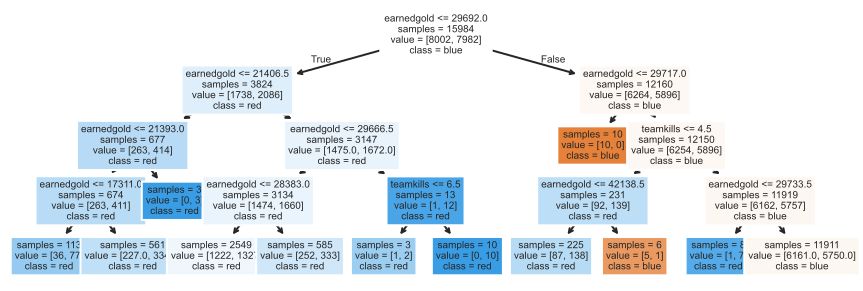

In [64]:
from sklearn.tree import plot_tree
plt.figure(figsize=(15, 5))
plot_tree(dj, feature_names=X_train.columns, class_names=['blue', 'red'], 
          filled=True, fontsize=10, impurity=False);

In [65]:
dj.score(X_test, y_test)

0.5152027027027027

In [66]:
win_rates_per_side = (teams[teams['result'] == 1].groupby('side').size() / teams.groupby('side').size()).to_frame().reset_index()

fig = px.bar(win_rates_per_side, x = 'side', y = 0, color='side', title = 'Win Rate Per Side', 
             color_discrete_map={'Blue': 'blue', 'Red': 'red'},)
fig.update_layout(yaxis_title="Win Rate")

In [67]:
fig = go.Figure()
fig.add_trace(go.Histogram(x=teams[teams['side'] == 'Red']['teamkills'], name='Red',marker_color='red'))
fig.add_trace(go.Histogram(x=teams[teams['side'] == 'Blue']['teamkills'], name='Blue',marker_color='blue'))
fig.update_layout(barmode='overlay')
fig.update_traces(opacity=0.55)
fig.update_layout(yaxis_title="count")
fig.update_layout(xaxis_title="total kills")
fig.update_layout(title="Total Kills by Side")

In [68]:
fig = go.Figure()
fig.add_trace(go.Histogram(x=teams[teams['side'] == 'Red']['earnedgold'], name='Red',marker_color='red'))
fig.add_trace(go.Histogram(x=teams[teams['side'] == 'Blue']['earnedgold'], name='Blue',marker_color='blue'))
fig.update_layout(barmode='overlay')
fig.update_traces(opacity=0.75)
fig.update_layout(yaxis_title="count")
fig.update_layout(xaxis_title="total earned gold")
fig.update_layout(title="Total Earned Gold by Side")

In [69]:
# TODO

## Step 6: Baseline Model

In [70]:
teams.head()

,gameid,league,side,teamname,...,xpat25,csat25,dragons,barons
10,ESPORTSTMNT01_2690210,LCKC,Blue,BRION Challengers,...,45960.0,767.0,1.0,0.0
11,ESPORTSTMNT01_2690210,LCKC,Red,Nongshim Esports Academy,...,49931.0,864.0,3.0,0.0
22,ESPORTSTMNT01_2690219,LCKC,Blue,T1 Esports Academy,...,49409.0,895.0,1.0,0.0
23,ESPORTSTMNT01_2690219,LCKC,Red,Liiv SANDBOX Youth,...,57155.0,928.0,4.0,2.0
46,ESPORTSTMNT01_2690227,LCKC,Blue,KT Rolster Challengers,...,52441.0,912.0,4.0,1.0


In [71]:
teams.columns

Index(['gameid', 'league', 'side', 'teamname', 'result', 'teamkills',
       'earnedgold', 'damagetochampions', 'xpat25', 'csat25', 'dragons',
       'barons'],
      dtype='object')

In [72]:
winners = teams[teams['result'] == 1][['gameid', 'side']]
winners.head()

,gameid,side
11,ESPORTSTMNT01_2690210,Red
23,ESPORTSTMNT01_2690219,Red
46,ESPORTSTMNT01_2690227,Blue
71,ESPORTSTMNT01_2690255,Red
94,ESPORTSTMNT01_2690264,Blue


In [73]:
complete_teams = complete[complete['position'] == 'team']

In [74]:
at_least_25 = complete_teams[complete_teams['gamelength'] >= 1500]

In [75]:
unique_games = at_least_25['gameid'].unique()

cols = ['teamkills',
       'earnedgold', 'damagetochampions', 'xpat25', 'csat25', 'dragons',
       'barons']

games_dict = {}
for game in unique_games:
    temp = at_least_25[at_least_25['gameid'] == game]
    
    diffs = []
    for col in cols:
        diff = -1 * (temp[col].diff().iloc[1])
        diffs.append(diff)
    
    games_dict[game] = diffs
    

In [76]:
diffs_df = pd.DataFrame(games_dict).T
diffs_df.columns = cols
diffs_df = diffs_df.merge(winners, how='inner', left_index=True, right_on='gameid')
diffs_df = diffs_df.set_index('gameid')
diffs_df = diffs_df.rename(columns={'side': 'winner'})
diffs_df

,teamkills,earnedgold,damagetochampions,xpat25,csat25,dragons,barons,winner
gameid,,,,,,,,
ESPORTSTMNT01_2690210,-10.0,-5547.0,-23352.0,-3971.0,-97.0,-2.0,-0.0,Red
ESPORTSTMNT01_2690219,-13.0,-13375.0,-15276.0,-7746.0,-33.0,-3.0,-2.0,Red
ESPORTSTMNT01_2690227,9.0,10691.0,21256.0,2532.0,5.0,3.0,1.0,Blue
...,...,...,...,...,...,...,...,...
ESPORTSTMNT01_3268686,-16.0,-10325.0,-22161.0,5476.0,129.0,-2.0,-1.0,Red
ESPORTSTMNT01_3269631,10.0,8771.0,2804.0,-899.0,-48.0,-1.0,-0.0,Blue
ESPORTSTMNT01_3268705,13.0,15074.0,33121.0,2143.0,30.0,4.0,1.0,Blue


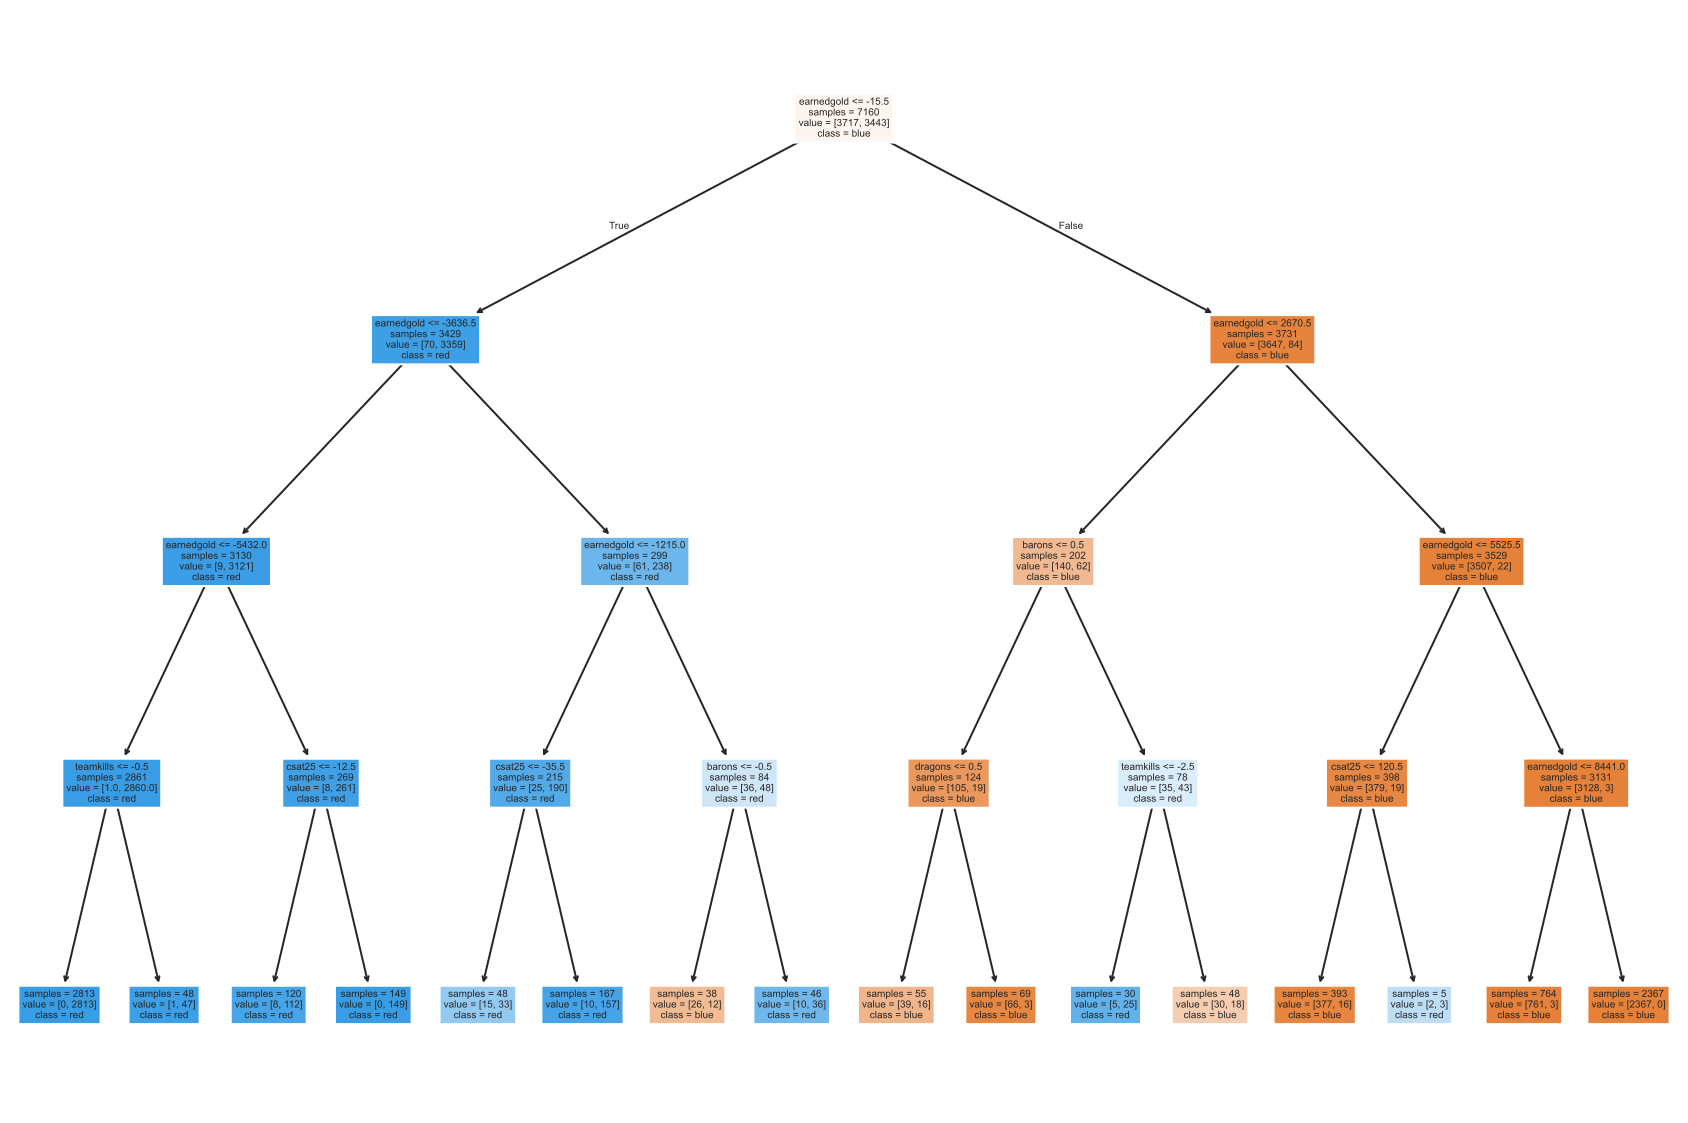

In [77]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = (
    train_test_split(diffs_df.drop(columns='winner'), diffs_df['winner'], random_state=1)
)

from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(max_depth=4, criterion='entropy')
dt.fit(X_train, y_train)


from sklearn.tree import plot_tree
plt.figure(figsize=(30, 20))
plot_tree(dt, feature_names=X_train.columns, class_names=['blue', 'red'], 
          filled=True, fontsize=10, impurity=False);

In [78]:
dt.score(X_test, y_test)

0.9782153330540427

In [79]:
dt.score(X_train, y_train)

0.9833798882681565

In [80]:
# Your code here

In [81]:
from sklearn.model_selection import GridSearchCV
hyperparameters = {
    'max_depth': [2, 3, 4, 5, 7, 10, 13, 15, 18, None], 
    'min_samples_split': [2, 5, 10, 20, 50, 100, 200],
    'criterion': ['gini', 'entropy']
}
len(hyperparameters['max_depth']) * \
len(hyperparameters['min_samples_split']) * \
len(hyperparameters['criterion'])
searcher = GridSearchCV(DecisionTreeClassifier(), hyperparameters, cv=5)
searcher.fit(X_train, y_train)
searcher.best_params_

{'criterion': 'gini', 'max_depth': 4, 'min_samples_split': 2}

In [82]:
searcher.cv_results_['mean_test_score']
pd.DataFrame(np.vstack([searcher.cv_results_[f'split{i}_test_score'] for i in range(5)]))

,0,1,2,3,...,136,137,138,139
0,0.98,0.98,0.98,0.98,...,0.98,0.98,0.98,0.98
1,0.98,0.98,0.98,0.98,...,0.98,0.97,0.97,0.97
2,0.98,0.98,0.98,0.98,...,0.98,0.98,0.98,0.98
3,0.98,0.98,0.98,0.98,...,0.98,0.98,0.98,0.98
4,0.97,0.97,0.97,0.97,...,0.97,0.97,0.97,0.97


In [83]:
searcher.best_params_


{'criterion': 'gini', 'max_depth': 4, 'min_samples_split': 2}

In [84]:
final_tree = DecisionTreeClassifier(**searcher.best_params_)
final_tree

DecisionTreeClassifier(max_depth=4)

In [85]:
final_tree.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=4)

In [86]:
final_tree.score(X_train, y_train)


0.9849162011173185

In [87]:
final_tree.score(X_test, y_test)


0.9782153330540427

## Step 7: Final Model

In [88]:
# TODO

## Step 8: Fairness Analysis

In [89]:
# TODO